In [45]:
import pandas as pd
from datetime import datetime
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import adfuller
import math
from sklearn.preprocessing import StandardScaler

## Data

In [46]:
# import data
df= pd.read_csv("import_2022.csv")

In [47]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 61 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   qa3_01         2605 non-null   int64
 1   qa3_02         2605 non-null   int64
 2   qa3_03         2605 non-null   int64
 3   qa3_04         2605 non-null   int64
 4   qa3_05         2605 non-null   int64
 5   qa3_06         2605 non-null   int64
 6   qa3_07         2605 non-null   int64
 7   qa3_08         2605 non-null   int64
 8   qa3_09         2605 non-null   int64
 9   qa4_01         2605 non-null   int64
 10  qa4_02         2605 non-null   int64
 11  qa4_03         2605 non-null   int64
 12  qa4_04         2605 non-null   int64
 13  qa4_05         2605 non-null   int64
 14  qa4_06         2605 non-null   int64
 15  qa4_07         2605 non-null   int64
 16  qa4_08         2605 non-null   int64
 17  qa4_09         2605 non-null   int64
 18  qa13_01        2605 non-null   int64
 19  qa13_0

None

## Risk Aversion

### Gain - 50%の確率で10万円が当たる「スピードくじ」の値段

Transformed price = 1 − λ/50,000 <br>
Note that the greater a respondent’s value of transformed price, the more risk averse the respondent is. In our setting, the values of transformed price only take values between zero and one, where the value of zero corresponds to the case of perfectly risk-neutral preference.

In [49]:
# Function to calculate calculate_price based on conditions
def calculate_price(row):
    conditions = {
        (2, 2, 2, 2, 2, 2, 2, 2): 0.9998,
        (1, 2, 2, 2, 2, 2, 2, 2): 0.9799,
        (1, 1, 2, 2, 2, 2, 2, 2): 0.94,
        (1, 1, 1, 2, 2, 2, 2, 2): 0.88,
        (1, 1, 1, 1, 2, 2, 2, 2): 0.77,
        (1, 1, 1, 1, 1, 2, 2, 2): 0.6,
        (1, 1, 1, 1, 1, 1, 2, 2): 0.4,
        (1, 1, 1, 1, 1, 1, 1, 2): 0.15,
        (1, 1, 1, 1, 1, 1, 1, 1): 0
        
    }
    # Ensure the order matches exactly as in your conditions dictionary
    key = (row['qa15_01'], row['qa15_02'], row['qa15_03'], row['qa15_04'],
           row['qa15_05'], row['qa15_06'], row['qa15_07'], row['qa15_08'])
    return conditions.get(key, 'unknown')  # return 'unknown' if no match is found

# Apply function to calculate rho
df['Risk_Gain'] = df.apply(calculate_price, axis=1)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 62 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qa3_01         2605 non-null   int64 
 1   qa3_02         2605 non-null   int64 
 2   qa3_03         2605 non-null   int64 
 3   qa3_04         2605 non-null   int64 
 4   qa3_05         2605 non-null   int64 
 5   qa3_06         2605 non-null   int64 
 6   qa3_07         2605 non-null   int64 
 7   qa3_08         2605 non-null   int64 
 8   qa3_09         2605 non-null   int64 
 9   qa4_01         2605 non-null   int64 
 10  qa4_02         2605 non-null   int64 
 11  qa4_03         2605 non-null   int64 
 12  qa4_04         2605 non-null   int64 
 13  qa4_05         2605 non-null   int64 
 14  qa4_06         2605 non-null   int64 
 15  qa4_07         2605 non-null   int64 
 16  qa4_08         2605 non-null   int64 
 17  qa4_09         2605 non-null   int64 
 18  qa13_01        2605 non-null

## Male 

In [51]:
df['Male'] = df['Male12'].apply(lambda x: 1 if x == 1 else 0)

## Marital Status

In [52]:
df['Spouse'] = df['qb2'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

## Age

In [53]:
# Function to calculate age
def calculate_age(year, month):
    today = datetime.today()
    birth_date = datetime(year, month, 1)
    age = today.year - birth_date.year - ((today.month, today.day) < (birth_date.month, birth_date.day))
    return age

# Create a new column for age
df['Age'] = df.apply(lambda row: calculate_age(row['qb3y'], row['qb3m']), axis=1)

## Housing

In [54]:
df['Residence'] = df['qb33'].apply(lambda x: 1 if x == 1 or x == 2 else 0)

## Income, Property, Financial Assets, 

In [55]:
# Income:
conditions = [
    (df['Income_pre'] == 1),
    (df['Income_pre'] == 2),
    (df['Income_pre'] == 3),
    (df['Income_pre'] == 4),
    (df['Income_pre'] == 5),
    (df['Income_pre'] == 6),
    (df['Income_pre'] == 7),
    (df['Income_pre'] == 8),
    (df['Income_pre'] == 9),
    (df['Income_pre'] == 10),
    (df['Income_pre'] == 11),
    (df['Income_pre'] == 12)
    
]

choices = [100, 150, 300, 500, 700, 900, 1100, 1300, 1500, 1700, 1900, 2000]

df['Income'] = np.select(conditions, choices, default=np.nan)

# Property:
conditions = [
    (df['Property_pre'] == 1),
    (df['Property_pre'] == 2),
    (df['Property_pre'] == 3),
    (df['Property_pre'] == 4),
    (df['Property_pre'] == 5),
    (df['Property_pre'] == 6),
    (df['Property_pre'] == 7),
    (df['Property_pre'] == 8),
    (df['Property_pre'] == 9),
    (df['Property_pre'] == 10)
]

choices = [0, 500, 750, 1250, 1750, 2500, 3500, 4500, 7500, 10000]

df['Property'] = np.select(conditions, choices, default=np.nan)

# Asset_Amt:
conditions = [
    (df['Fin_Asset_pre'] == 1),
    (df['Fin_Asset_pre'] == 2),
    (df['Fin_Asset_pre'] == 3),
    (df['Fin_Asset_pre'] == 4),
    (df['Fin_Asset_pre'] == 5),
    (df['Fin_Asset_pre'] == 6),
    (df['Fin_Asset_pre'] == 7),
    (df['Fin_Asset_pre'] == 8),
    (df['Fin_Asset_pre'] == 9),
    (df['Fin_Asset_pre'] == 10)
]

choices = [250, 375, 625, 875, 1250, 1750, 2500, 4000, 7500, 10000]

df['Fin_Asset'] = np.select(conditions, choices, default=np.nan)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 69 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   qa3_01         2605 non-null   int64  
 1   qa3_02         2605 non-null   int64  
 2   qa3_03         2605 non-null   int64  
 3   qa3_04         2605 non-null   int64  
 4   qa3_05         2605 non-null   int64  
 5   qa3_06         2605 non-null   int64  
 6   qa3_07         2605 non-null   int64  
 7   qa3_08         2605 non-null   int64  
 8   qa3_09         2605 non-null   int64  
 9   qa4_01         2605 non-null   int64  
 10  qa4_02         2605 non-null   int64  
 11  qa4_03         2605 non-null   int64  
 12  qa4_04         2605 non-null   int64  
 13  qa4_05         2605 non-null   int64  
 14  qa4_06         2605 non-null   int64  
 15  qa4_07         2605 non-null   int64  
 16  qa4_08         2605 non-null   int64  
 17  qa4_09         2605 non-null   int64  
 18  qa13_01 

## Asset Type

In [57]:
# List of columns to check
columns_to_check = [f'qb36{str(i).zfill(2)}' for i in range(1, 15)]

# Filter out rows with any value of 9 in the specified columns
# df_cleaned = df[~df[columns_to_check].isin([9]).any(axis=1)].copy()

# Instead of deleting rows, keep all rows and set 9 -> NaN
df_cleaned = df.copy()
df_cleaned[columns_to_check] = df_cleaned[columns_to_check].replace(9, np.nan)


In [58]:
# １ 銀行預金（信用金庫、信用組合、農協などを含む）
# ２ 郵便貯金 ３ 生命保険 ４ 株式 
# ５ 投資信託 ６ 外貨預金 ７ 先物・オプション
# ８ 日本の国債 ９ 外国債 10 個人年金（生命保険会社や郵便年金）
# 11 企業年金 12 現金貯金（いわゆるタンス預金）
# 13 その他（ ）

# List of columns to sum for Asset_Type, excluding qb3608
columns_to_sum = [f'qb36{str(i).zfill(2)}' for i in range(4, 9)]

# Create the new column 'Asset_Type' by summing the specified columns
# df_cleaned['Asset_Type'] = df_cleaned[columns_to_sum].sum(axis=1)

# - if all components are NaN => Asset_Type becomes NaN (not 0)
df_cleaned['Asset_Type'] = df_cleaned[columns_to_sum].sum(axis=1, min_count=1)

In [59]:
# df_cleaned['Stock'] = df['qb3604'].apply(lambda x: 1 if x == 1 else 0)
# df_cleaned['MF'] = df['qb3605'].apply(lambda x: 1 if x == 1 else 0)

# If qb3604 is missing => Stock should be missing too (not forced to 0)
df_cleaned['Stock'] = np.where(
    df_cleaned['qb3604'].isna(),
    np.nan,
    np.where(df_cleaned['qb3604'] == 1, 1, 0)
)

df_cleaned['MF'] = np.where(
    df_cleaned['qb3605'].isna(),
    np.nan,
    np.where(df_cleaned['qb3605'] == 1, 1, 0)
)

In [60]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 72 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   qa3_01         2605 non-null   int64  
 1   qa3_02         2605 non-null   int64  
 2   qa3_03         2605 non-null   int64  
 3   qa3_04         2605 non-null   int64  
 4   qa3_05         2605 non-null   int64  
 5   qa3_06         2605 non-null   int64  
 6   qa3_07         2605 non-null   int64  
 7   qa3_08         2605 non-null   int64  
 8   qa3_09         2605 non-null   int64  
 9   qa4_01         2605 non-null   int64  
 10  qa4_02         2605 non-null   int64  
 11  qa4_03         2605 non-null   int64  
 12  qa4_04         2605 non-null   int64  
 13  qa4_05         2605 non-null   int64  
 14  qa4_06         2605 non-null   int64  
 15  qa4_07         2605 non-null   int64  
 16  qa4_08         2605 non-null   int64  
 17  qa4_09         2605 non-null   int64  
 18  qa13_01 

In [61]:
#df_filtered = df_cleaned[(df_cleaned['Risk_Gain'] != 'unknown')]

df_filtered = df_cleaned.copy()

# Convert the special string to missing (keep rows)
df_filtered["Risk_Gain"] = df_filtered["Risk_Gain"].replace("unknown", np.nan)

# Convert to numeric; non-numeric values become NaN safely
df_filtered["Risk_Gain"] = pd.to_numeric(df_filtered["Risk_Gain"], errors="coerce")


df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 72 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   qa3_01         2605 non-null   int64  
 1   qa3_02         2605 non-null   int64  
 2   qa3_03         2605 non-null   int64  
 3   qa3_04         2605 non-null   int64  
 4   qa3_05         2605 non-null   int64  
 5   qa3_06         2605 non-null   int64  
 6   qa3_07         2605 non-null   int64  
 7   qa3_08         2605 non-null   int64  
 8   qa3_09         2605 non-null   int64  
 9   qa4_01         2605 non-null   int64  
 10  qa4_02         2605 non-null   int64  
 11  qa4_03         2605 non-null   int64  
 12  qa4_04         2605 non-null   int64  
 13  qa4_05         2605 non-null   int64  
 14  qa4_06         2605 non-null   int64  
 15  qa4_07         2605 non-null   int64  
 16  qa4_08         2605 non-null   int64  
 17  qa4_09         2605 non-null   int64  
 18  qa13_01 

In [62]:
# Drop columns starting with 'qa'
columns_to_drop = [col for col in df_filtered.columns if col.startswith('q')]
df_filtered = df_filtered.drop(columns=columns_to_drop)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rain           2605 non-null   int64  
 1   Male12         2605 non-null   int64  
 2   Income_pre     2605 non-null   int64  
 3   Property_pre   2605 non-null   int64  
 4   Fin_Asset_pre  2605 non-null   int64  
 5   Risky_Asset    2605 non-null   int64  
 6   Risk_Gain      2477 non-null   float64
 7   Male           2605 non-null   int64  
 8   Spouse         2605 non-null   int64  
 9   Age            2605 non-null   int64  
 10  Residence      2605 non-null   int64  
 11  Income         2392 non-null   float64
 12  Property       2395 non-null   float64
 13  Fin_Asset      2294 non-null   float64
 14  Asset_Type     2493 non-null   float64
 15  Stock          2493 non-null   float64
 16  MF             2493 non-null   float64
dtypes: float64(7), int64(10)
memory usage: 346.1 KB


In [63]:
df_filtered = df_filtered.drop(columns=['Male12','Income_pre','Property_pre','Fin_Asset_pre'])

In [64]:
df_filtered = df_filtered.drop(columns=['Asset_Type', 'Risky_Asset'])

In [65]:
# Further filter the DataFrame based on the specified conditions
# conditions = (
#     (df_filtered['Rain'] != 999) 
# )

# df_filtered = df_filtered[conditions]

# Instead of filtering out Rain == 999, set it to missing (NaN)
df_filtered.loc[df_filtered["Rain"] == 999, "Rain"] = np.nan

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rain       2521 non-null   float64
 1   Risk_Gain  2477 non-null   float64
 2   Male       2605 non-null   int64  
 3   Spouse     2605 non-null   int64  
 4   Age        2605 non-null   int64  
 5   Residence  2605 non-null   int64  
 6   Income     2392 non-null   float64
 7   Property   2395 non-null   float64
 8   Fin_Asset  2294 non-null   float64
 9   Stock      2493 non-null   float64
 10  MF         2493 non-null   float64
dtypes: float64(7), int64(4)
memory usage: 224.0 KB


Complete-Case Dataset

In [67]:
# -----------------------------
# 0) CONFIG: set analysis columns
# -----------------------------
# If you already have these lists defined in your script, keep them.
continuous_cols = ['Rain', 'Income', 'Property', 'Fin_Asset', 'Risk_Gain', 'Age']
categorical_cols = ['Male', 'Spouse', 'Residence', 'Stock', 'MF']

analysis_cols = continuous_cols + categorical_cols

# -----------------------------
# 1) Create complete-case sample & excluded sample
# -----------------------------
mask_complete = df_filtered[analysis_cols].notna().all(axis=1)

df_complete = df_filtered.loc[mask_complete, analysis_cols].copy()
df_excluded = df_filtered.loc[~mask_complete, analysis_cols].copy()

print(f"Total rows:        {len(df_filtered):,}")
print(f"Complete-case:     {len(df_complete):,}")
print(f"Excluded (missing):{len(df_excluded):,}")

Total rows:        2,605
Complete-case:     2,056
Excluded (missing):549


In [68]:
# -----------------------------
# 2) Missingness summary (helps address Reviewer 3)
# -----------------------------
missing_summary = pd.DataFrame({
    "missing_n": df_filtered[analysis_cols].isna().sum(),
    "missing_rate": df_filtered[analysis_cols].isna().mean()
}).sort_values("missing_rate", ascending=False)

print("\nMissingness summary (analysis variables):")
print(missing_summary)



Missingness summary (analysis variables):
           missing_n  missing_rate
Fin_Asset        311      0.119386
Income           213      0.081766
Property         210      0.080614
Risk_Gain        128      0.049136
Stock            112      0.042994
MF               112      0.042994
Rain              84      0.032246
Age                0      0.000000
Male               0      0.000000
Spouse             0      0.000000
Residence          0      0.000000


In [69]:
# -----------------------------
# 3) Helper functions for SMD and proportion differences
# -----------------------------
def standardized_mean_difference(x_complete: pd.Series, x_excluded: pd.Series) -> float:
    """SMD = (mean1 - mean0) / pooled_sd, using sample SD (ddof=1)."""
    a = pd.to_numeric(x_complete, errors="coerce").dropna()
    b = pd.to_numeric(x_excluded, errors="coerce").dropna()

    if len(a) < 2 or len(b) < 2:
        return np.nan

    m1, m0 = a.mean(), b.mean()
    s1, s0 = a.std(ddof=1), b.std(ddof=1)
    pooled = np.sqrt((s1**2 + s0**2) / 2.0)

    if pooled == 0 or np.isnan(pooled):
        return np.nan

    return float((m1 - m0) / pooled)

def is_binary_01(s: pd.Series) -> bool:
    """Detect binary variables encoded as {0,1} or boolean, ignoring NaNs."""
    vals = pd.Series(s.dropna().unique())
    if vals.empty:
        return False
    if s.dropna().dtype == bool:
        return True
    return set(vals.tolist()).issubset({0, 1})

# -----------------------------
# 4) Continuous-variable comparison (SMD + descriptive stats)
# -----------------------------
cont_rows = []
for col in continuous_cols:
    a = df_complete[col]
    b = df_excluded[col]

    # Descriptives
    a_num = pd.to_numeric(a, errors="coerce")
    b_num = pd.to_numeric(b, errors="coerce")

    row = {
        "variable": col,
        "n_complete": int(a_num.notna().sum()),
        "n_excluded": int(b_num.notna().sum()),
        "mean_complete": float(a_num.mean()),
        "mean_excluded": float(b_num.mean()),
        "sd_complete": float(a_num.std(ddof=1)),
        "sd_excluded": float(b_num.std(ddof=1)),
        "median_complete": float(a_num.median()),
        "median_excluded": float(b_num.median()),
        "p25_complete": float(a_num.quantile(0.25)),
        "p25_excluded": float(b_num.quantile(0.25)),
        "p75_complete": float(a_num.quantile(0.75)),
        "p75_excluded": float(b_num.quantile(0.75)),
        "SMD": standardized_mean_difference(a_num, b_num),
    }
    cont_rows.append(row)

comparison_continuous = pd.DataFrame(cont_rows).set_index("variable")
print("\nContinuous-variable comparison (SMD):")
print(comparison_continuous)

# -----------------------------
# 5) Binary-variable comparison (difference in proportions)
# -----------------------------
# We will include any variable in analysis_cols that looks binary {0,1} or bool.
binary_candidates = [c for c in analysis_cols if is_binary_01(df_filtered[c])]

bin_rows = []
for col in binary_candidates:
    a = df_complete[col].dropna()
    b = df_excluded[col].dropna()

    # Convert bool -> int, keep 0/1 otherwise
    a01 = a.astype(int) if a.dtype == bool else a.astype(float)
    b01 = b.astype(int) if b.dtype == bool else b.astype(float)

    # Proportion of 1s
    p1_complete = float(a01.mean()) if len(a01) > 0 else np.nan
    p1_excluded = float(b01.mean()) if len(b01) > 0 else np.nan

    bin_rows.append({
        "variable": col,
        "n_complete": int(len(a01)),
        "n_excluded": int(len(b01)),
        "p1_complete": p1_complete,
        "p1_excluded": p1_excluded,
        "diff_in_proportions": p1_complete - p1_excluded if (np.isfinite(p1_complete) and np.isfinite(p1_excluded)) else np.nan
    })

comparison_binary = pd.DataFrame(bin_rows).set_index("variable")
print("\nBinary-variable comparison (difference in proportions):")
print(comparison_binary)



Continuous-variable comparison (SMD):
           n_complete  n_excluded  mean_complete  mean_excluded  sd_complete  \
variable                                                                       
Rain             2056         465      45.925584      45.569892    19.831058   
Income           2056         336     600.024319     534.375000   402.744537   
Property         2056         339    2011.551556    1985.250737  2148.703921   
Fin_Asset        2056         238    1926.070039    1807.247899  2236.535152   
Risk_Gain        2056         421       0.771642       0.796318     0.210487   
Age              2056         549      66.505350      69.488160    11.759221   

           sd_excluded  median_complete  median_excluded  p25_complete  \
variable                                                                 
Rain         20.590631            50.00            50.00         30.00   
Income      370.761495           500.00           500.00        300.00   
Property   2165.867041  

## Imputation 

In [22]:
from statsmodels.imputation.mice import MICEData
impute_cols = [
    "Rain","Risk_Gain","Male","Spouse","Age","Residence",
    "Income","Property","Fin_Asset","Stock","MF"
]


In [23]:
def generate_mice_datasets(df_in, impute_cols, m=5, burnin=10, between=5):
    df_work = df_in[impute_cols].copy()  
    
    mice_data = MICEData(df_work)

    for _ in range(burnin):
        mice_data.update_all()

    out = []
    for _ in range(m):
        for __ in range(between):
            mice_data.update_all()
        out.append(mice_data.data.copy())

    return out

imputed_list = generate_mice_datasets(df_filtered, impute_cols, m=5)

In [24]:
def postprocess_imputed(df_imp: pd.DataFrame) -> pd.DataFrame:
    out = df_imp.copy()

    # Binary variables
    for c in ["Male", "Spouse", "Residence","Stock", "MF"]:
        out[c] = np.round(out[c]).clip(0, 1).astype(int)

    # Bounds (adjust if needed)
    out["Age"] = out["Age"].clip(0, 100)
    out["Rain"] = out["Rain"].clip(0, 100)
    out["Risk_Gain"] = out["Risk_Gain"].clip(0, 1)

    # Nonnegative financial vars
    for c in ["Income", "Property", "Fin_Asset"]:
        out[c] = out[c].clip(lower=0)

    return out

imputed_list = [postprocess_imputed(dfi) for dfi in imputed_list]


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

continuous_cols = ["Rain", "Risk_Gain", "Age", "Income", "Property", "Fin_Asset"]
categorical_cols = ["Male", "Spouse", "Residence", "Stock", "MF"]

# Fit scaler once (consistent scaling across imputations)
# Note: fit requires no NaNs; use dropna on these columns
scaler = StandardScaler(with_mean=False, with_std=True)
scaler.fit(df_filtered[continuous_cols].dropna().values)

def apply_normalization(df_in: pd.DataFrame, scaler, continuous_cols):
    out = df_in.copy()
    out[continuous_cols] = scaler.transform(out[continuous_cols].values)
    return out

imputed_list_norm = [apply_normalization(dfi, scaler, continuous_cols) for dfi in imputed_list]

print("Imputed datasets:", len(imputed_list_norm))
print("Remaining missing (first):", imputed_list_norm[0].isna().sum().sum())
print(imputed_list_norm[0].head())

Imputed datasets: 5
Remaining missing (first): 0
       Rain  Risk_Gain  Male  Spouse       Age  Residence    Income  Property  \
0  2.519260   4.741191     1       1  6.387246          1  0.745206  0.232975   
1  2.015408   1.896856     1       1  6.216920          1  0.745206  0.232975   
2  2.015408   2.845284     1       1  5.024634          1  1.242010  0.232975   
3  3.023112   4.173083     0       1  6.046593          1  1.738814  3.494623   
4  3.023112   1.896856     0       1  4.683981          1  3.229225  1.630824   

   Fin_Asset  Stock  MF  
0   0.167865      0   0  
1   0.559551      1   0  
2   0.279775      0   0  
3   3.357305      0   0  
4   0.559551      0   1  


In [26]:
imputed_list_norm[4][impute_cols].isna().sum()

Rain         0
Risk_Gain    0
Male         0
Spouse       0
Age          0
Residence    0
Income       0
Property     0
Fin_Asset    0
Stock        0
MF           0
dtype: int64

In [27]:
imputed_list_norm[4].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2605 entries, 0 to 2604
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Rain       2605 non-null   float64
 1   Risk_Gain  2605 non-null   float64
 2   Male       2605 non-null   int64  
 3   Spouse     2605 non-null   int64  
 4   Age        2605 non-null   float64
 5   Residence  2605 non-null   int64  
 6   Income     2605 non-null   float64
 7   Property   2605 non-null   float64
 8   Fin_Asset  2605 non-null   float64
 9   Stock      2605 non-null   int64  
 10  MF         2605 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 224.0 KB


# FCI

https://causal-learn.readthedocs.io/en/latest/search_methods_index/Constraint-based%20causal%20discovery%20methods/FCI.html#algorithm-introduction

In [28]:
#「PC/FCIにおいて混合データを扱うための機能の実装」に対応した causal-learn をインストールするためには、次のコマンドを実行します。
#!pip install git+https://github.com/cdt15/causal-learn.git

In [29]:
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.cit import kci
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
# visualization
from causallearn.utils.GraphUtils import GraphUtils
import pydot
import io
import matplotlib.image as mpimg

In [30]:
vars_order = [
    "Rain",
    "Risk_Gain",
    "Male",
    "Spouse",
    "Age",
    "Residence",
    "Income",
    "Property",
    "Fin_Asset",
    "Stock",
    "MF"
]

is_discrete = [False, False, True, True, False, True, False, False, False, True, True]


In [31]:
from causallearn.graph.GraphNode import GraphNode
nodes = [GraphNode(f"X{i}") for i in range(1, 12)]

forbidden_edges = [
    (0,2),(1,2),(3,2),(4,2),(5,2),(6,2),(7,2),(8,2),(9,2),(10,2),
    (0,4),(1,4),(2,4),(3,4),(5,4),(6,4),(7,4),(8,4),(9,4),(10,4)
]

bk = BackgroundKnowledge()
for (node_1_idx, node_2_idx) in forbidden_edges:
    bk.add_forbidden_by_node(nodes[node_1_idx], nodes[node_2_idx])

In [32]:
def run_fci_once(df_one):
    # Ensure correct column order
    data_pre = df_one[vars_order].to_numpy()

    G, edges = fci(
        data_pre,
        is_discrete=is_discrete,
        independence_test_method="kci",
        background_knowledge=bk
    )
    return G, edges


In [33]:
datasets = imputed_list_norm  # or imputed_list

Gs = []
Edges = []

for i, dfi in enumerate(datasets, 1):
    G, edges = run_fci_once(dfi)
    Gs.append(G)
    Edges.append(edges)
    print(f"Finished FCI on imputation {i}/{len(datasets)}")

  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
X9 --> X10
Finished FCI on imputation 1/5


  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
X9 --> X10
Finished FCI on imputation 2/5


  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
Finished FCI on imputation 3/5


  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X4
X8 --> X6
X8 --> X7
X8 --> X10
X9 --> X10
Finished FCI on imputation 4/5


  0%|          | 0/11 [00:00<?, ?it/s]

Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): X5 --> X1
Orienting edge (Knowledge): X3 --> X2
Orienting edge (Knowledge): X5 --> X2
Orienting edge (Knowledge): X3 --> X4
Orienting edge (Knowledge): X3 --> X10
Orienting edge (Knowledge): X5 --> X4
Orienting edge (Knowledge): X5 --> X7
Orienting edge (Knowledge): X5 --> X9
Finishing BK Orientation.
X7 --> X2
X7 --> X4
X8 --> X7
X9 --> X8
Finished FCI on imputation 5/5


In [34]:
def plot_pag(G):
    pyd = GraphUtils.to_pydot(G, labels=vars_order)
    tmp_png = pyd.create_png(f="png")
    fp = io.BytesIO(tmp_png)
    img = mpimg.imread(fp, format="png")
    plt.figure(figsize=(16, 16))
    plt.axis("off")
    plt.imshow(img)
    plt.show()


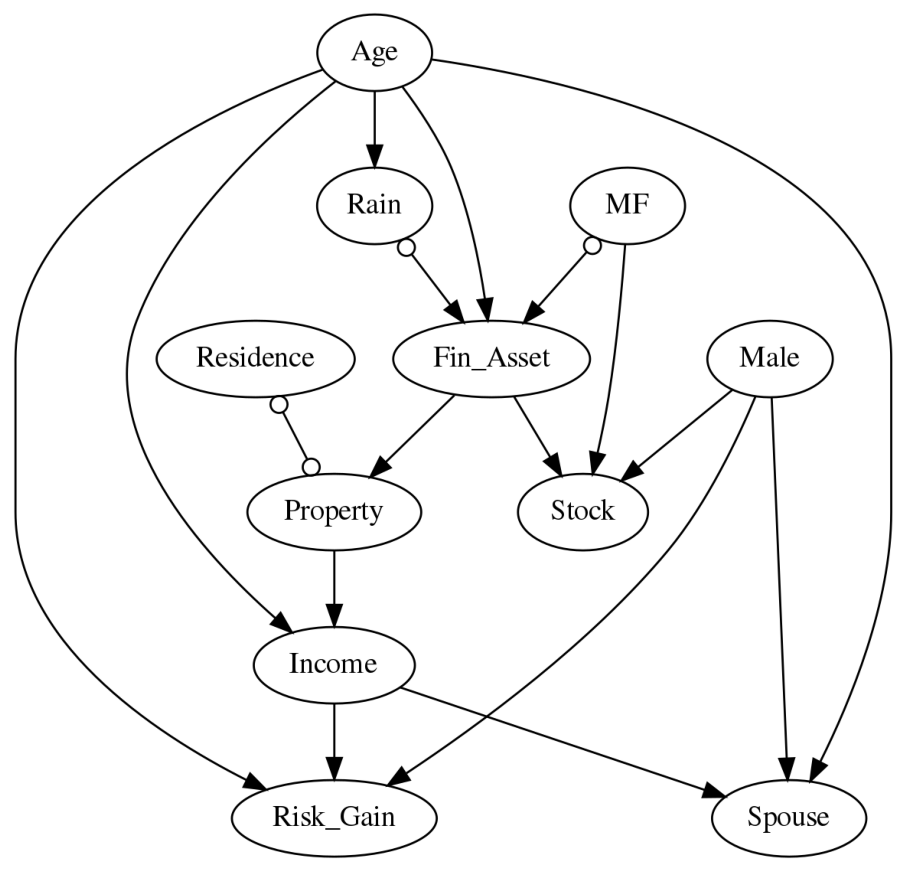

In [35]:
plot_pag(Gs[0])   # show imputation 1

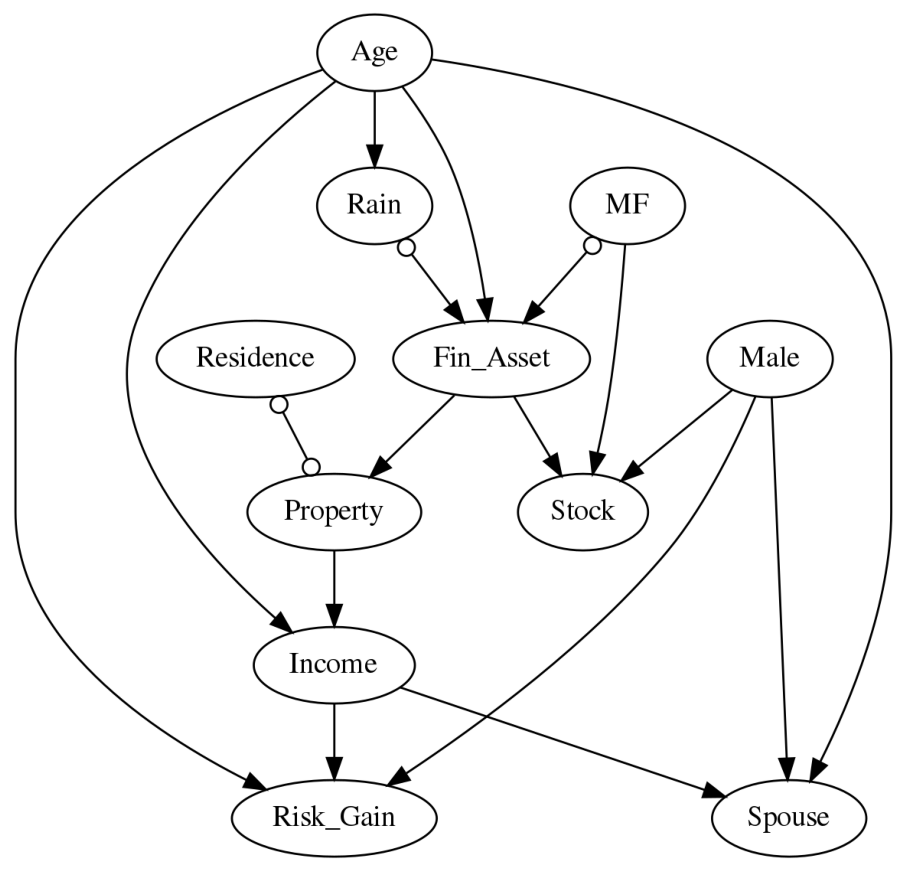

In [38]:
plot_pag(Gs[1])   

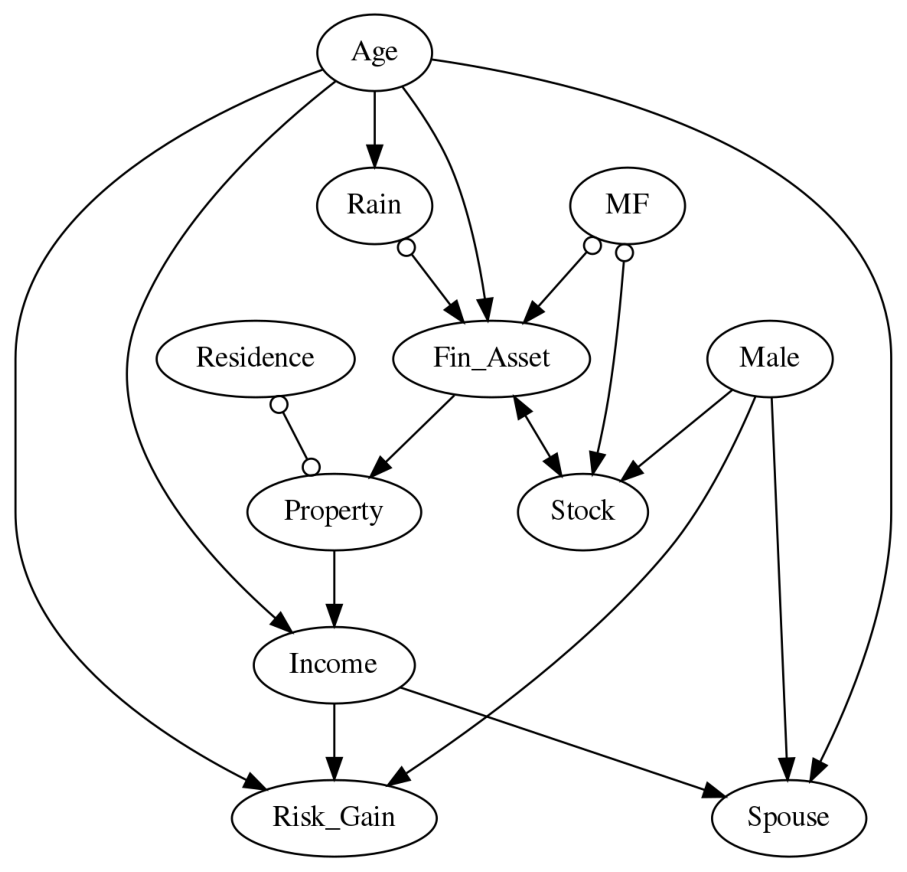

In [39]:
plot_pag(Gs[2])   

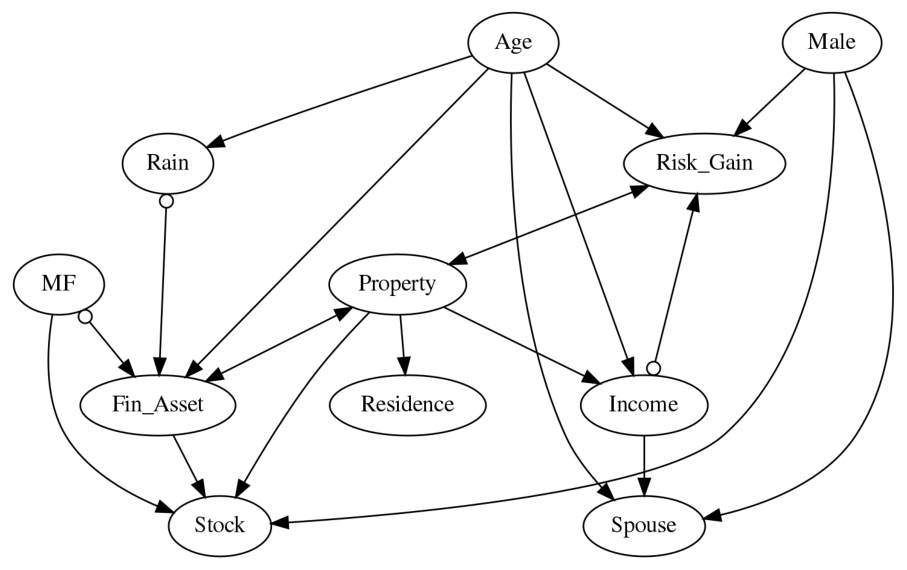

In [40]:
plot_pag(Gs[3])   

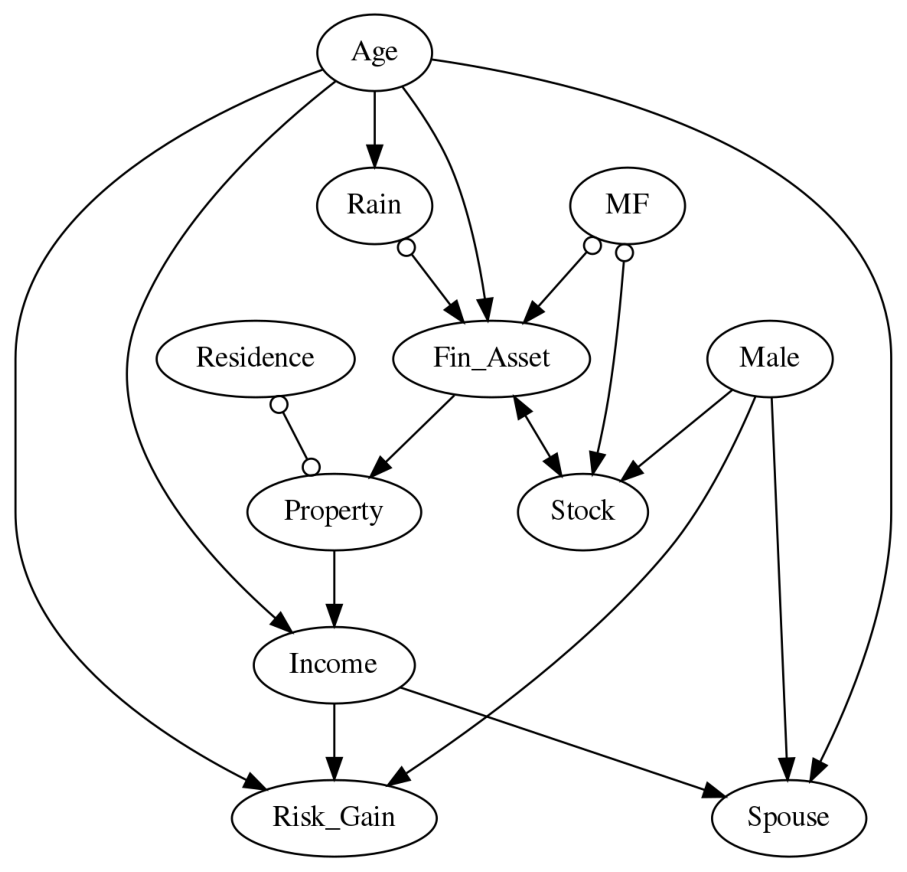

In [41]:
plot_pag(Gs[4])   

In [44]:
from collections import Counter

def edge_signature(G):
    # returns a set of edge strings like "X3 o-> X7" depending on marks
    sig = set()
    for e in G.get_graph_edges():
        n1 = e.get_node1().get_name()
        n2 = e.get_node2().get_name()
        sig.add(str(e))  # simplest; includes endpoint marks
    return sig

edge_counts = Counter()
for G in Gs:
    for e in edge_signature(G):
        edge_counts[e] += 1

# show edges that appear in >= 4 of 5 imputations (adjust threshold)
m = len(Gs)
stable = [(e, c) for e, c in edge_counts.items() ]
stable = sorted(stable, key=lambda x: (-x[1], x[0]))

print("Edges stable across imputations:")
for e, c in stable[:50]:
    print(f"{c}/{m}  {e}")

Edges stable across imputations:
5/5  X1 o-> X9
5/5  X11 o-> X9
5/5  X3 --> X10
5/5  X3 --> X2
5/5  X3 --> X4
5/5  X5 --> X1
5/5  X5 --> X2
5/5  X5 --> X4
5/5  X5 --> X7
5/5  X5 --> X9
5/5  X7 --> X4
5/5  X8 --> X7
4/5  X6 o-o X8
4/5  X7 --> X2
4/5  X9 --> X8
3/5  X11 --> X10
3/5  X9 --> X10
2/5  X11 o-> X10
2/5  X9 <-> X10
1/5  X2 <-> X8
1/5  X7 o-> X2
1/5  X8 --> X10
1/5  X8 --> X6
1/5  X8 <-> X9
